In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load datasets
users = pd.read_csv("users.csv", parse_dates=["signup_date"])
subscriptions = pd.read_csv("subscriptions.csv", parse_dates=["start_date", "end_date"])
events = pd.read_csv("events.csv", parse_dates=["event_date"])

print("Data Loaded Successfully")

Data Loaded Successfully


In [4]:
#Total Signups
total_signups = users['user_id'].nunique()
print("Total Signups:", total_signups)

Total Signups: 2000


In [5]:
#Engaged users
engaged_users = events[events['event_type'] == 'feature_use']['user_id'].nunique()
print("Engaged Users:", engaged_users)

Engaged Users: 1926


In [6]:
#Paid users
paid_users = subscriptions[subscriptions['plan_type'].isin(['Basic', 'Pro'])]['user_id'].nunique()

print("Paid Users:", paid_users)

Paid Users: 988


In [7]:
#Calculate Conversion Rates
engagement_rate = engaged_users / total_signups * 100
trial_to_paid_rate = paid_users / total_signups * 100
engaged_to_paid_rate = paid_users / engaged_users * 100

print(f"Engagement Rate: {round(engagement_rate,2)}%")
print(f"Trial to Paid Conversion: {round(trial_to_paid_rate,2)}%")
print(f"Engaged to Paid Conversion: {round(engaged_to_paid_rate,2)}%")

Engagement Rate: 96.3%
Trial to Paid Conversion: 49.4%
Engaged to Paid Conversion: 51.3%


In [ ]:
#To export data for power bi
conversion_df = pd.DataFrame({
    "Metric": [
        "Engagement Rate",
        "Trial to Paid",
        "Engaged to Paid"
    ],
    "Value (%)": [
        round(engagement_rate, 2),
        round(trial_to_paid_rate, 2),
        round(engaged_to_paid_rate, 2)
    ]
})

print(conversion_df)


            Metric  Value (%)
0  Engagement Rate       96.3
1    Trial to Paid       49.4
2  Engaged to Paid       51.3


In [9]:
conversion_df.to_csv("conversion_data.csv", index=False)

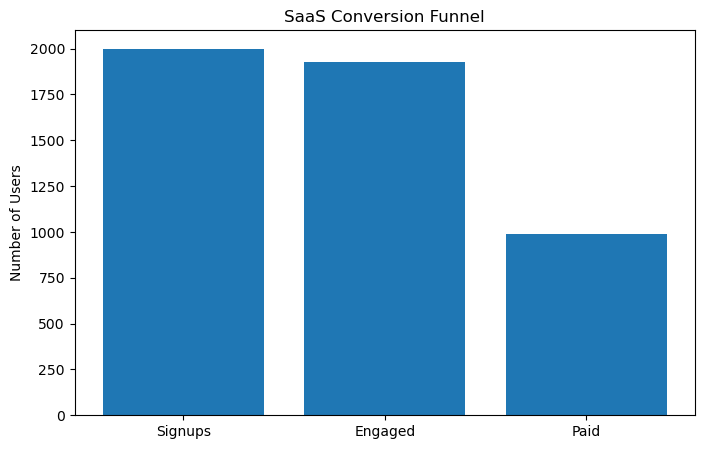

In [10]:
#Visual Funnel
funnel_data = {
    "Stage": ["Signups", "Engaged", "Paid"],
    "Users": [total_signups, engaged_users, paid_users]
}

funnel_df = pd.DataFrame(funnel_data)

plt.figure(figsize=(8,5))
plt.bar(funnel_df["Stage"], funnel_df["Users"])
plt.title("SaaS Conversion Funnel")
plt.ylabel("Number of Users")
plt.show()